In [10]:
# shell
# python -m venv .venv       

# In cmd.exe
# .venv\Scripts\activate.bat

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
from tqdm.notebook import tqdm

import torch
import torch.nn.functional as F
from torch import nn
from torch import Tensor
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

In [3]:
import myVAE
importlib.reload(myVAE)

from myVAE import VAE

In [4]:
# https://www.kaggle.com/datasets/infamouscoder/dataset-netflix-shows
# https://www.kaggle.com/code/samad0015/eda-on-netflix-shows
path = "../data/netflix_titles.csv"
df = pd.read_csv(path)

df.shape

(8807, 12)

In [5]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [6]:
states = []

for line in df['country'].unique():
    if pd.isna(line):
        states.append("undefined")
        continue 
    for state in line.replace(", ", ",").split(","):
        states.append(state)


np.unique(np.array(states))

array(['', 'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas',
       'Bangladesh', 'Belarus', 'Belgium', 'Bermuda', 'Botswana',
       'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon',
       'Canada', 'Cayman Islands', 'Chile', 'China', 'Colombia',
       'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark',
       'Dominican Republic', 'East Germany', 'Ecuador', 'Egypt',
       'Ethiopia', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait',
       'Latvia', 'Lebanon', 'Liechtenstein', 'Lithuania', 'Luxembourg',
       'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Mongolia',
       'Montenegro', 'Morocco', 'Mozambique', 'Namibia', 'Nepal',
       'Netherlands', 'New Zealand', 'Ni

Try GPT

In [ ]:
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
import tqdm

With context

In [18]:

# Load a BERT model (for embeddings)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# List of strings (e.g. actor names)
texts = ["Brad Pitt", "Edward Norton", "Helena Bonham Carter"]

# Tokenize
inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)

# Disable gradient tracking
with torch.no_grad():
    outputs = model(**inputs)
    token_embeddings = outputs.last_hidden_state  # shape: (batch_size, seq_len, hidden_dim)

# Mean pool over tokens (dim=1)
sentence_embeddings = token_embeddings.mean(dim=1)

print("Embedding shape:", sentence_embeddings.shape)  # torch.Size([3, 768])

Embedding shape: torch.Size([3, 768])


<br>

EMB

In [406]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
# model_name = "bert-base-uncased"                # Load a BERT model 
model_name = "gpt2"                               # Load a GPT2 model 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token 

In [ ]:
states_emb = []

for i, line in enumerate(df['country']):
    text = ["movie county unknown"] if pd.isna(line) else line.replace(", ", ",").split(",")
    # inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    # inputs = tokenizer(text, return_tensors="pt", truncation=True)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, return_attention_mask=True, padding=True,)

    with torch.no_grad():
        outputs = model(**inputs)
        token_embeddings = outputs.last_hidden_state             # shape: (batch_size, seq_len, hidden_dim)
        last_embedding = token_embeddings[:, -1, :]

    sentence_embeddings = last_embedding.mean(dim=0).squeeze()   # Mean pool over tokens (dim=1)
    states_emb.append(sentence_embeddings)
    print("\r", f"iteration {i+1} / {len(df['country'])}: \t {token_embeddings.shape} \t {text} ", end=' '*100)

    


 iteration 8807 / 8807: 	 torch.Size([1, 1, 768]) 	 ['India']                                                                                                                                                                                                                                                  

In [ ]:
actor_emb = []

for i, line in enumerate(df['director']):
    text = ["actors unknown"] if pd.isna(line) else line.replace(", ", ",").split(",")
    # inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    # inputs = tokenizer(text, return_tensors="pt", truncation=True)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, return_attention_mask=True, padding=True,)

    with torch.no_grad():
        outputs = model(**inputs)
        token_embeddings = outputs.last_hidden_state             # shape: (batch_size, seq_len, hidden_dim)
        last_embedding = token_embeddings[:, -1, :]

    sentence_embeddings = last_embedding.mean(dim=0).squeeze()   # Mean pool over tokens (dim=1)
    actor_emb.append(sentence_embeddings)
    print("\r", f"iteration {i+1} / {len(df['country'])}: \t {token_embeddings.shape} \t {text} ", end=' '*100)

    

 iteration 8807 / 8807: 	 torch.Size([1, 4, 768]) 	 ['Mozez Singh']                                                                                                                                                                                                                                                                                                                                

In [10]:
listed_in_set = []

for i, line in enumerate(df['listed_in'].unique()):
    text = line.replace(", ", ",").replace(" & ", ",").split(",")
    [listed_in_set.append(t) for t in text]

listed_in_set.append('unknown')
listed_in_set = set(listed_in_set)
listed_in_set

{'Action',
 'Adventure',
 'Anime Features',
 'Anime Series',
 'British TV Shows',
 'Children',
 'Classic',
 'Classic Movies',
 'Comedies',
 'Crime TV Shows',
 'Cult Movies',
 'Cult TV',
 'Documentaries',
 'Docuseries',
 'Dramas',
 'Faith',
 'Family Movies',
 'Fantasy',
 'Horror Movies',
 'Independent Movies',
 'International Movies',
 'International TV Shows',
 "Kids' TV",
 'Korean TV Shows',
 'LGBTQ Movies',
 'Movies',
 'Music',
 'Musicals',
 'Nature TV',
 'Reality TV',
 'Romantic Movies',
 'Romantic TV Shows',
 'Sci-Fi',
 'Science',
 'Spanish-Language TV Shows',
 'Spirituality',
 'Sports Movies',
 'Stand-Up Comedy',
 'TV Action',
 'TV Comedies',
 'TV Dramas',
 'TV Horror',
 'TV Mysteries',
 'TV Sci-Fi',
 'TV Shows',
 'TV Thrillers',
 'Talk Shows',
 'Teen TV Shows',
 'Thrillers',
 'unknown'}

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

c:\Users\david\Documents\GitHub\MLOpsProject\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\david\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed

In [663]:
listed_in_embedded = {}
for i, line in enumerate(listed_in_set):
    inputs = tokenizer(line, return_tensors="pt", truncation=True, return_attention_mask=True, padding=True,)
    
    with torch.no_grad():
        outputs = model(**inputs)
        token_embeddings = outputs.last_hidden_state             # shape: (batch_size, seq_len, hidden_dim)
        last_embedding = token_embeddings[:, -1, :]
    
    sentence_embeddings = token_embeddings.mean(dim=0).squeeze()   # Mean pool over tokens (dim=1)
    
    listed_in_embedded[line] = sentence_embeddings

In [664]:
list_emb = []

for i, line in enumerate(df['listed_in']):
    text = "unknown" if pd.isna(line) else line.replace(", ", ",").replace(" & ", ",").split(",")
    
    token_embeddings = torch.vstack([listed_in_embedded[t] for t in text])
    sentence_embeddings = token_embeddings.mean(dim=0).squeeze()

    list_emb.append(sentence_embeddings)
    print("\r", f"iteration {i+1} / {len(df['listed_in'])}:  \t {text} ", end=' '*50)


 iteration 8807 / 8807:  	 ['Dramas', 'International Movies', 'Music', 'Musicals']                                                                                    

In [75]:
list_emb = []

for i, line in enumerate(df['listed_in']):
    text = "film genre unknown" if pd.isna(line) else "film genre: " + line
    
    sentence_embeddings = model.encode(text, normalize_embeddings=True)
    list_emb.append(sentence_embeddings)

    print("\r", f"iteration {i+1} / {len(df['listed_in'])}:  \t {text} ", end=' '*50)


 iteration 8807 / 8807:  	 film genre: Dramas, International Movies, Music & Musicals                                                                                    

In [ ]:
"""listed_in_embedded = {}
for i, line in enumerate(listed_in_set):
    sentence_embeddings = torch.zeros(len(listed_in_set))
    sentence_embeddings[i] = 1
    listed_in_embedded[line] = sentence_embeddings"""

In [ ]:
"""list_emb = []

for i, line in enumerate(df['listed_in']):
    text = "unknown" if pd.isna(line) else line.replace(", ", ",").replace(" & ", ",").split(",")
    
    token_embeddings = torch.vstack([listed_in_embedded[t] for t in text])
    sentence_embeddings = token_embeddings.sum(dim=0).squeeze()

    list_emb.append(sentence_embeddings)
    print("\r", f"iteration {i+1} / {len(df['listed_in'])}:  \t {text} ", end=' '*50)
"""

 iteration 8807 / 8807:  	 ['Dramas', 'International Movies', 'Music', 'Musicals']                                                                                    

VAE

In [22]:
from torch.utils.data import DataLoader

import myVAE
importlib.reload(myVAE)

from myVAE import VAE
from myVAE import VAEc

In [116]:
vae = VAE(list_emb[0].shape[0], 10)

In [117]:
epochs = 10
optimizer = torch.optim.Adam(vae.parameters(), lr = 1e-5)
print(sum(p.numel() for p in vae.parameters())/1e3, 'K parameters')

188.18 K parameters


In [118]:
list_emb[0].shape

(384,)

In [119]:
train_loader = DataLoader(list_emb, shuffle=True, batch_size=32)

In [121]:
for epoch in range(epochs):
    vae.train()
    for x in train_loader:
        x = x.view(-1, vae.in_dim)
        
        x_hat, mu, log_var = vae(x)
        loss = vae.loss(x_hat, mu, log_var, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"epoch: {epoch + 1} / {epochs} \t loss: {loss}")   

epoch: 1 / 10 	 loss: 0.5416670441627502
epoch: 2 / 10 	 loss: 0.620417058467865
epoch: 3 / 10 	 loss: 0.4864215850830078
epoch: 4 / 10 	 loss: 0.5948145985603333
epoch: 5 / 10 	 loss: 0.446199893951416
epoch: 6 / 10 	 loss: 0.5335648059844971
epoch: 7 / 10 	 loss: 0.45453575253486633
epoch: 8 / 10 	 loss: 0.5436974167823792
epoch: 9 / 10 	 loss: 0.4870395362377167
epoch: 10 / 10 	 loss: 0.4700198471546173


In [122]:
# X = torch.stack(list_emb)
X = torch.tensor(list_emb)

In [83]:
from sklearn.manifold import TSNE

In [209]:
X_np=np.array(list_emb)

In [139]:
X_np = vae.encode(X)[0].detach().numpy()

In [131]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=40)

X_tsne = tsne.fit_transform(X_np)

In [137]:
choose_element = np.zeros(df.shape[0], dtype='int32')
for i, line in enumerate(df['listed_in']):
    if not pd.isna(line) and "TV Comedies" in line:
        choose_element[i] = 2
            
    if 'Horror' in line:
        choose_element[i] = 1

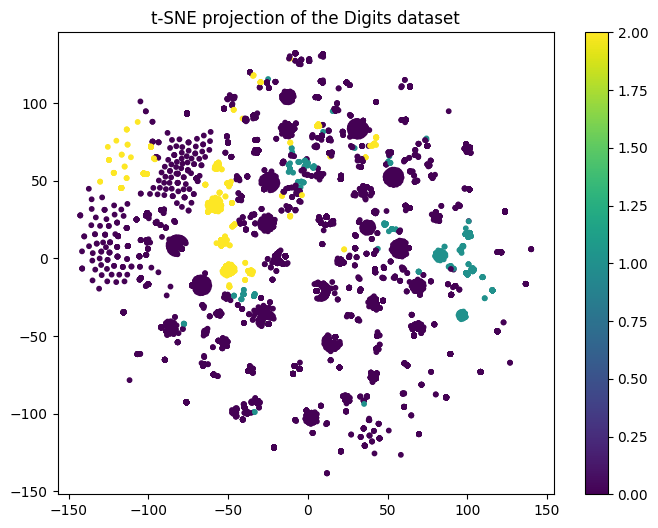

In [138]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=choose_element, s=10)
plt.colorbar()
plt.title("t-SNE projection of the Digits dataset")
plt.show()

In [199]:
"""inputs = tokenizer('Comedies', return_tensors="pt", truncation=True, return_attention_mask=True, padding=True,)

with torch.no_grad():
    outputs = model(**inputs)
    token_embeddings = outputs.last_hidden_state             # shape: (batch_size, seq_len, hidden_dim)
    last_embedding = token_embeddings[:, -1, :]

sentence_embeddings = token_embeddings.mean(dim=1)

print(sentence_embeddings.shape)
comparison_z = vae.encode(sentence_embeddings)[0].detach().numpy().squeeze()


comparison_z = vae.encode(listed_in_embedded['Comedies'].unsqueeze(0))[0].detach().numpy().squeeze()
""" 

comparison_z = torch.tensor( model.encode(['Comedies'],  normalize_embeddings=True))
comparison_z = vae.encode(comparison_z)[0].detach().numpy().squeeze()

# distances = np.sqrt(np.sum((comparison_z - X_np)**2, axis = 1))
distances = (X_np @ comparison_z) / (np.linalg.norm(comparison_z) * np.linalg.norm(X_np, axis=1))
idx = np.argsort(-distances)

In [223]:
comparison_z = model.encode(['Comedies'],  normalize_embeddings=True)
# distances = np.sqrt(np.sum((comparison_z - np.array(X))**2, axis = 1))

distances = (X_np @ comparison_z.T) / (np.linalg.norm(comparison_z) * np.linalg.norm(X_np, axis=1, keepdims=True))
distances= distances.squeeze()

idx = np.argsort(-distances.squeeze())



In [224]:
for i in idx:
    print(f"{i} \t distance: {distances[i]*10: .4f} \t list_in: {df['listed_in'][i]}") 

8087 	 distance:  8.6823 	 list_in: Comedies
3309 	 distance:  8.6823 	 list_in: Comedies
6655 	 distance:  8.6823 	 list_in: Comedies
27 	 distance:  8.6823 	 list_in: Comedies
1459 	 distance:  8.6823 	 list_in: Comedies
7003 	 distance:  8.6823 	 list_in: Comedies
1446 	 distance:  8.6823 	 list_in: Comedies
8130 	 distance:  8.6823 	 list_in: Comedies
2159 	 distance:  8.6823 	 list_in: Comedies
6377 	 distance:  8.6823 	 list_in: Comedies
3583 	 distance:  8.6823 	 list_in: Comedies
3662 	 distance:  8.6823 	 list_in: Comedies
7014 	 distance:  8.6823 	 list_in: Comedies
7015 	 distance:  8.6823 	 list_in: Comedies
6340 	 distance:  8.6823 	 list_in: Comedies
2115 	 distance:  8.6823 	 list_in: Comedies
888 	 distance:  8.6823 	 list_in: Comedies
912 	 distance:  8.6823 	 list_in: Comedies
6061 	 distance:  8.6823 	 list_in: Comedies
7316 	 distance:  8.6823 	 list_in: Comedies
6583 	 distance:  8.6823 	 list_in: Comedies
6303 	 distance:  8.6823 	 list_in: Comedies
931 	 distance

In [ ]:
import faiss
import numpy as np

# 1. Generate embeddings for movie overviews
model = load_embedding_model()
embeddings = model.encode([movie["overview"] for movie in movies])

# 2. Build a FAISS index
dim = embeddings.shape[1]  # Dimension of embeddings (e.g., 384 for MiniLM)
index = faiss.IndexFlatL2(dim)  # L2 distance for similarity
index.add(embeddings)  # Add embeddings to index

# 3. Search for similar movies
query = "A movie about space exploration"
query_embedding = model.encode([query])
k = 5  # Number of similar movies to retrieve
distances, indices = index.search(query_embedding, k)

# 4. Get the top similar movies
similar_movies = [movies[i] for i in indices[0]]